# Preprocessing — Gemcitabine Drug Response

This notebook rebuilds the 3-way merge, constructs the feature matrix `X` and target `y`, encodes tissue lineage, filters low-variance genes, and visualises two dimensionality reduction options (Pearson correlation and PCA) so the user can choose the approach before splitting/saving arrays.

**Scope:** Stops after PCA visualisation. Review the 5 output plots and decide the feature selection strategy before the next notebook.

---
## Section 0 — Imports & Config

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

# ── Plot style ───────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_DIR  = '../data/'
GDSC_PATH = DATA_DIR + 'GDSC2_fitted_dose_response_27Oct23.csv'
MODEL_PATH = DATA_DIR + 'Model.csv'
EXPR_PATH  = DATA_DIR + 'OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv'

# ── Output directory (all plots saved here) ──────────────────────────────────
OUTPUT_DIR = '../output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Hyperparameters ──────────────────────────────────────────────────────────
VARIANCE_THRESHOLD = 0.1
TOP_N_CORR_GENES   = 2000
N_PCA_COMPONENTS   = 50
MIN_LINEAGE_COUNT  = 5
RANDOM_SEED        = 42

TARGET_DRUG = 'Gemcitabine'

print('Setup complete.')
print(f'Plots will be saved to: {os.path.abspath(OUTPUT_DIR)}')

Setup complete.
Plots will be saved to: /app/output


---
## Section 1 — Rebuild 3-Way Merge

Replicates the merge pipeline from `notebooks/innitial_EDA.ipynb` exactly:
1. GDSC2 × Model.csv on `COSMIC_ID`
2. Filter expression to `IsDefaultEntryForModel == 'Yes'` (string, not bool)
3. Filter to Gemcitabine, dedup by `['COSMIC_ID', 'DRUG_NAME', 'ModelID']` only

In [2]:
# ── 1a. Load GDSC2 ───────────────────────────────────────────────────────────
gdsc = pd.read_csv(GDSC_PATH)
print(f'GDSC2 shape: {gdsc.shape}')

GDSC2 shape: (242036, 19)


In [3]:
# ── 1b. Load Model.csv and clean COSMIC_ID ───────────────────────────────────
model = pd.read_csv(MODEL_PATH, low_memory=False)
model_clean = (
    model[['ModelID', 'CellLineName', 'COSMICID', 'OncotreeLineage']]
    .rename(columns={'COSMICID': 'COSMIC_ID'})
    .dropna(subset=['COSMIC_ID'])
    .copy()
)
model_clean['COSMIC_ID'] = model_clean['COSMIC_ID'].astype(int)
print(f'Model entries with valid COSMIC_ID: {len(model_clean):,}')

Model entries with valid COSMIC_ID: 977


In [4]:
# ── 1c. Load Expression and keep only default entries ────────────────────────
print('Loading expression matrix (may take ~30s)...')
expr_raw = pd.read_csv(EXPR_PATH)
if expr_raw.columns[0].startswith('Unnamed'):
    expr_raw = expr_raw.drop(columns=[expr_raw.columns[0]])

# Keep one canonical expression profile per cell line
expr = expr_raw[expr_raw['IsDefaultEntryForModel'] == 'Yes'].copy()

meta_cols = ['ModelID', 'SequencingID', 'IsDefaultEntryForModel',
             'ModelConditionID', 'IsDefaultEntryForMC']
gene_cols = [c for c in expr.columns if c not in meta_cols]
expr_final = expr[['ModelID'] + gene_cols].copy()

print(f'Expression matrix: {expr_final.shape[0]:,} cell lines × {len(gene_cols):,} genes')

Loading expression matrix (may take ~30s)...


Expression matrix: 1,699 cell lines × 19,215 genes


In [5]:
# ── 1d. GDSC2 × Model join ───────────────────────────────────────────────────
gdsc_model = gdsc.merge(model_clean, on='COSMIC_ID', how='inner')

# Keep only rows whose ModelID appears in the expression matrix
expr_ids = set(expr_final['ModelID'].unique())
gdsc_model = gdsc_model[gdsc_model['ModelID'].isin(expr_ids)].copy()

# Filter to target drug
gem_raw = gdsc_model[gdsc_model['DRUG_NAME'] == TARGET_DRUG].copy()

# Dedup: one LN_IC50 per (COSMIC_ID, DRUG_NAME, ModelID) — never include TCGA_DESC
# (NaN values in TCGA_DESC would silently drop rows via pandas dropna=True default)
target_df = (
    gem_raw
    .groupby(['COSMIC_ID', 'DRUG_NAME', 'ModelID'], as_index=False)
    .agg(
        CellLineName=('CellLineName', 'first'),
        OncotreeLineage=('OncotreeLineage', 'first'),
        TCGA_DESC=('TCGA_DESC', 'first'),
        LN_IC50=('LN_IC50', 'mean'),
        AUC=('AUC', 'mean'),
    )
)

print(f'Target drug: {TARGET_DRUG}')
print(f'Cell lines after 3-way merge + dedup: {len(target_df):,}')
print(target_df['LN_IC50'].describe())

Target drug: Gemcitabine
Cell lines after 3-way merge + dedup: 694
count   694.0000
mean     -0.6294
std       3.0344
min      -6.3367
25%      -3.1444
50%      -1.0078
75%       1.7566
max       7.7169
Name: LN_IC50, dtype: float64


---
## Section 2 — Build Gemcitabine Feature Matrix

Inner-join `target_df` with `expr_final` on `ModelID` to produce:
- `X_raw`: `(694, 19215)` float32 gene expression matrix
- `y`: `(694,)` LN_IC50 values

In [6]:
merged = target_df.merge(expr_final, on='ModelID', how='inner')

# Confirm gene columns are the same set (they should be)
gene_cols_present = [c for c in gene_cols if c in merged.columns]

X_raw = merged[gene_cols_present].values.astype(np.float32)
y     = merged['LN_IC50'].values.astype(np.float32)

# Store metadata for later use (tissue type, cell line names)
meta = merged[['ModelID', 'COSMIC_ID', 'CellLineName', 'OncotreeLineage', 'TCGA_DESC']].copy()

assert not np.isnan(X_raw).any(), 'NaNs found in X_raw!'
assert not np.isnan(y).any(),     'NaNs found in y!'

print(f'X_raw shape: {X_raw.shape}')
print(f'y shape:     {y.shape}')
print(f'y range:     [{y.min():.4f}, {y.max():.4f}]')
print('No NaNs detected.')

X_raw shape: (694, 19215)
y shape:     (694,)
y range:     [-6.3367, 7.7169]
No NaNs detected.


---
## Section 3 — Encode OncotreeLineage

`OncotreeLineage` is used (not `TCGA_DESC`, which has nulls) for stratified splitting later. Rare lineages (< `MIN_LINEAGE_COUNT`) are collapsed to `"Other"` to avoid stratification issues.

In [7]:
lineage_series = meta['OncotreeLineage'].fillna('Unknown')

# Remap rare lineages to 'Other'
counts = lineage_series.value_counts()
rare = counts[counts < MIN_LINEAGE_COUNT].index
lineage_remapped = lineage_series.where(~lineage_series.isin(rare), other='Other')

le = LabelEncoder()
lineage_encoded = le.fit_transform(lineage_remapped)

meta = meta.copy()
meta['lineage_label']   = lineage_remapped.values
meta['lineage_encoded'] = lineage_encoded

print(f'Lineages before remapping: {lineage_series.nunique()}')
print(f'Rare lineages collapsed:   {len(rare)}')
print(f'Final lineage classes:     {len(le.classes_)}')
print(f'Class names: {list(le.classes_)}')

Lineages before remapping: 27
Rare lineages collapsed:   5
Final lineage classes:     23
Class names: ['Bladder/Urinary Tract', 'Bone', 'Bowel', 'Breast', 'CNS/Brain', 'Cervix', 'Esophagus/Stomach', 'Head and Neck', 'Kidney', 'Liver', 'Lung', 'Lymphoid', 'Myeloid', 'Other', 'Ovary/Fallopian Tube', 'Pancreas', 'Peripheral Nervous System', 'Pleura', 'Prostate', 'Skin', 'Soft Tissue', 'Thyroid', 'Uterus']


---
## Section 4 — Low-Variance Gene Filtering

Genes with near-zero variance across all cell lines carry no predictive signal and add noise. We plot the variance distribution, then apply `VarianceThreshold`.

In [8]:
# Compute per-gene variance
gene_variances = X_raw.var(axis=0)

print(f'Gene variance — min: {gene_variances.min():.6f}, '
      f'median: {np.median(gene_variances):.4f}, '
      f'max: {gene_variances.max():.4f}')
print(f'Genes below threshold ({VARIANCE_THRESHOLD}): '
      f'{(gene_variances < VARIANCE_THRESHOLD).sum():,}')

Gene variance — min: 0.000000, median: 0.5593, max: 16.3258
Genes below threshold (0.1): 2,395


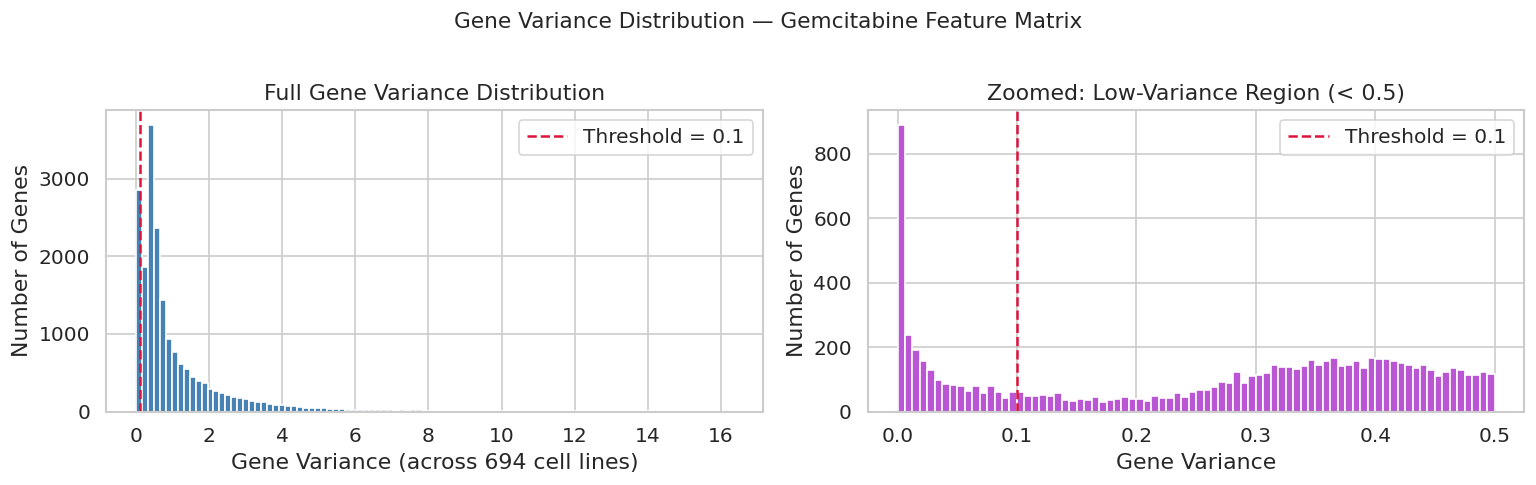

In [9]:
# ── Plot: gene variance distribution ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Full distribution
axes[0].hist(gene_variances, bins=100, color='steelblue', edgecolor='white')
axes[0].axvline(VARIANCE_THRESHOLD, color='crimson', linestyle='--', linewidth=1.5,
                label=f'Threshold = {VARIANCE_THRESHOLD}')
axes[0].set_xlabel('Gene Variance (across 694 cell lines)')
axes[0].set_ylabel('Number of Genes')
axes[0].set_title('Full Gene Variance Distribution')
axes[0].legend()

# Zoomed low-variance region
axes[1].hist(gene_variances[gene_variances < 0.5], bins=80,
             color='mediumorchid', edgecolor='white')
axes[1].axvline(VARIANCE_THRESHOLD, color='crimson', linestyle='--', linewidth=1.5,
                label=f'Threshold = {VARIANCE_THRESHOLD}')
axes[1].set_xlabel('Gene Variance')
axes[1].set_ylabel('Number of Genes')
axes[1].set_title('Zoomed: Low-Variance Region (< 0.5)')
axes[1].legend()

plt.suptitle('Gene Variance Distribution — Gemcitabine Feature Matrix', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'gene_variance_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ── Apply variance threshold ──────────────────────────────────────────────────
selector = VarianceThreshold(threshold=VARIANCE_THRESHOLD)
X_var_filtered = selector.fit_transform(X_raw)

surviving_mask       = selector.get_support()
surviving_gene_names = [gene_cols_present[i] for i, keep in enumerate(surviving_mask) if keep]

n_dropped   = X_raw.shape[1] - X_var_filtered.shape[1]
n_surviving = X_var_filtered.shape[1]

print(f'Genes before filtering:  {X_raw.shape[1]:,}')
print(f'Genes dropped (var < {VARIANCE_THRESHOLD}): {n_dropped:,}')
print(f'Genes surviving:         {n_surviving:,}')
print(f'X_var_filtered shape:    {X_var_filtered.shape}')

Genes before filtering:  19,215
Genes dropped (var < 0.1): 2,395
Genes surviving:         16,820
X_var_filtered shape:    (694, 16820)


---
## Section 5 — Pearson Correlation Visualisation

Rank genes by their absolute Pearson r with LN_IC50. This is a simple, interpretable feature selection strategy.

**Biological sanity check:** DCK and SLC29A1 are known Gemcitabine sensitivity markers and should appear in the top-ranked genes.

In [11]:
# Compute Pearson r for every surviving gene vs LN_IC50
print('Computing Pearson correlations (may take ~10s)...')
r_values = np.array([
    stats.pearsonr(X_var_filtered[:, j], y)[0]
    for j in range(X_var_filtered.shape[1])
])
abs_r = np.abs(r_values)

# Build a sorted DataFrame
corr_df = pd.DataFrame({
    'gene': surviving_gene_names,
    'pearson_r': r_values,
    'abs_r': abs_r,
}).sort_values('abs_r', ascending=False).reset_index(drop=True)

# The top-N cutoff value
cutoff_r = corr_df.iloc[TOP_N_CORR_GENES - 1]['abs_r'] if TOP_N_CORR_GENES <= len(corr_df) else 0

print(f'Top-{TOP_N_CORR_GENES} gene |r| cutoff: {cutoff_r:.4f}')
print(f'\nTop 20 genes by |Pearson r|:')
print(corr_df[['gene', 'pearson_r', 'abs_r']].head(20).to_string(index=False))

Computing Pearson correlations (may take ~10s)...


Top-2000 gene |r| cutoff: 0.2191

Top 20 genes by |Pearson r|:
            gene  pearson_r  abs_r
  SLFN11 (91607)    -0.4541 0.4541
  HDAC11 (79885)     0.4465 0.4465
   NHSL3 (57648)     0.4440 0.4440
    TUFT1 (7286)     0.4312 0.4312
CEP170B (283638)     0.4284 0.4284
  NCKAP1L (3071)    -0.4279 0.4279
     TJP1 (7082)     0.4184 0.4184
    SOX13 (9580)     0.4172 0.4172
    PTPRF (5792)     0.4122 0.4122
  EPB41L1 (2036)     0.4097 0.4097
    PTPRC (5788)    -0.4078 0.4078
 ANKLE1 (126549)    -0.4060 0.4060
      WAS (7454)    -0.4056 0.4056
    ERBB2 (2064)     0.4022 0.4022
     PPIC (5480)     0.4010 0.4010
 STARD10 (10809)     0.4006 0.4006
     SDC4 (6385)     0.4002 0.4002
   IKZF1 (10320)    -0.3996 0.3996
     RPL3 (6122)    -0.3976 0.3976
   GIPC1 (10755)     0.3969 0.3969


In [12]:
# ── Biological sanity check ───────────────────────────────────────────────────
MARKERS = ['DCK', 'SLC29A1']
for marker in MARKERS:
    matches = corr_df[corr_df['gene'].str.startswith(marker + ' ')]
    if not matches.empty:
        row = matches.iloc[0]
        rank = corr_df[corr_df['gene'] == row['gene']].index[0] + 1
        print(f'  {marker}: rank={rank}, r={row["pearson_r"]:.4f} (|r|={row["abs_r"]:.4f})')
    else:
        print(f'  {marker}: NOT FOUND — check gene name format in surviving_gene_names')

  DCK: rank=621, r=-0.2926 (|r|=0.2926)
  SLC29A1: rank=5796, r=-0.1287 (|r|=0.1287)


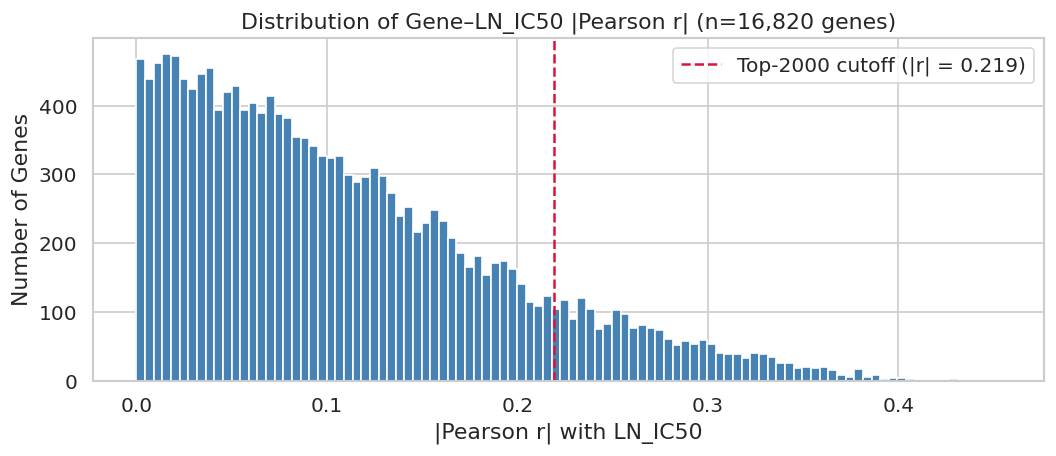

In [13]:
# ── Plot 1: Distribution of |Pearson r| with top-N cutoff line ────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(abs_r, bins=100, color='steelblue', edgecolor='white')
ax.axvline(cutoff_r, color='crimson', linestyle='--', linewidth=1.5,
           label=f'Top-{TOP_N_CORR_GENES} cutoff (|r| = {cutoff_r:.3f})')
ax.set_xlabel('|Pearson r| with LN_IC50')
ax.set_ylabel('Number of Genes')
ax.set_title(f'Distribution of Gene–LN_IC50 |Pearson r| (n={len(abs_r):,} genes)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'pearson_correlation_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

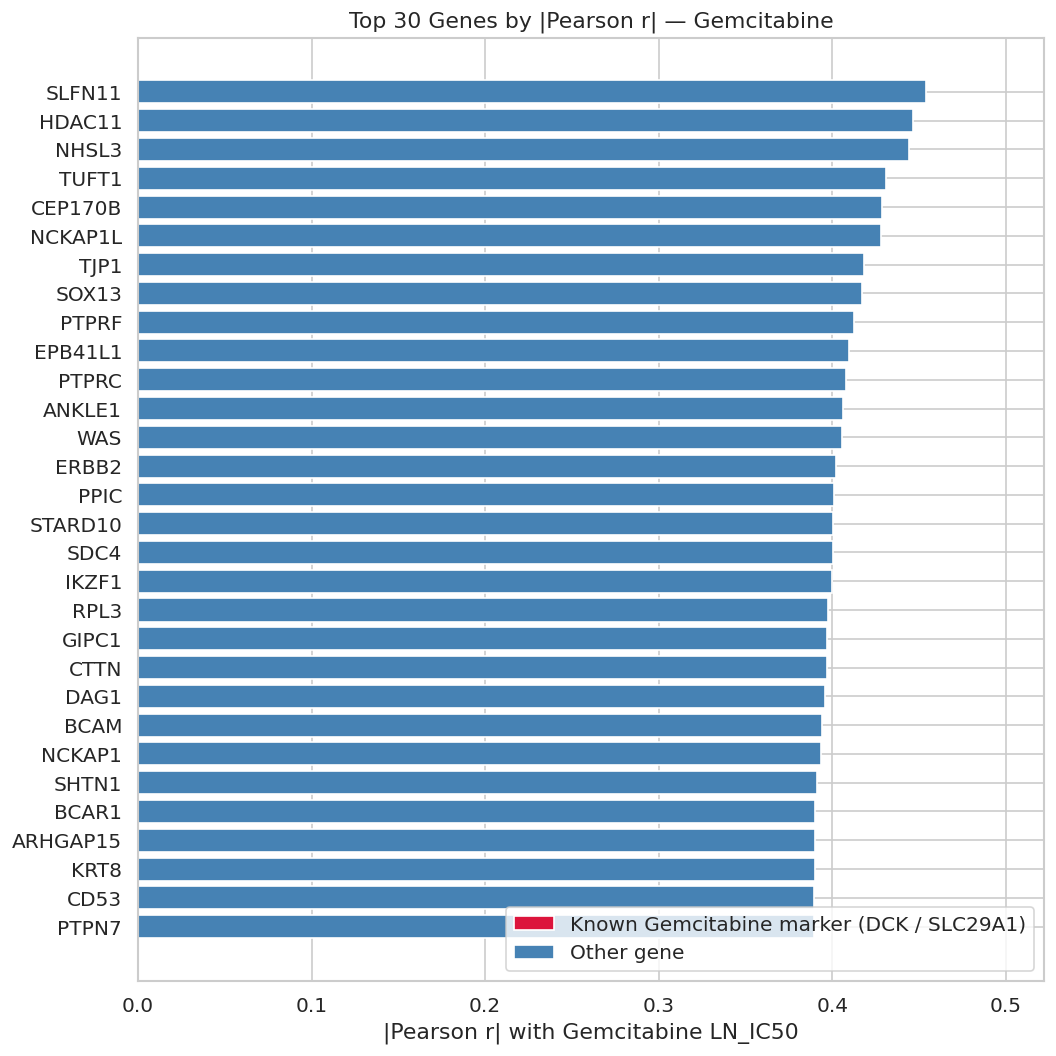

In [14]:
# ── Plot 2: Top 30 genes horizontal bar chart, DCK/SLC29A1 highlighted ────────
top30 = corr_df.head(30).copy()

# Identify known Gemcitabine markers for highlighting
def is_marker(gene_name):
    return any(gene_name.startswith(m + ' ') or gene_name == m for m in MARKERS)

colors = ['crimson' if is_marker(g) else 'steelblue' for g in top30['gene']]

# Clean gene labels: strip Entrez ID suffix for readability
top30['label'] = top30['gene'].str.replace(r' \(\d+\)$', '', regex=True)

fig, ax = plt.subplots(figsize=(9, 9))
bars = ax.barh(top30['label'][::-1], top30['abs_r'][::-1],
               color=colors[::-1], edgecolor='white')

# Legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='crimson',   label='Known Gemcitabine marker (DCK / SLC29A1)'),
    Patch(facecolor='steelblue', label='Other gene'),
]
ax.legend(handles=legend_elements, loc='lower right')

ax.set_xlabel('|Pearson r| with Gemcitabine LN_IC50')
ax.set_title('Top 30 Genes by |Pearson r| — Gemcitabine')
ax.set_xlim(0, top30['abs_r'].max() * 1.15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'top_genes_pearson.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Section 6 — PCA Visualisation

Standardise `X_var_filtered` and fit PCA to understand how much variance can be compressed into fewer dimensions, and whether LN_IC50 or tissue type separates in PC space.

**Notebook ends here.** Review the 5 saved plots and decide the dimensionality reduction strategy before the next notebook (splitting + saving arrays).

In [15]:
# ── Scale and fit PCA ─────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_var_filtered)

pca = PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X_scaled)

explained      = pca.explained_variance_ratio_
cumulative     = np.cumsum(explained)
n_for_90pct    = int(np.searchsorted(cumulative, 0.90)) + 1

print(f'PC1 variance explained:  {explained[0]*100:.2f}%')
print(f'PC2 variance explained:  {explained[1]*100:.2f}%')
print(f'Cumulative at PC{N_PCA_COMPONENTS}: {cumulative[-1]*100:.2f}%')
print(f'Components needed for 90% variance: {n_for_90pct}')

PC1 variance explained:  10.29%
PC2 variance explained:  7.20%
Cumulative at PC50: 57.78%
Components needed for 90% variance: 51


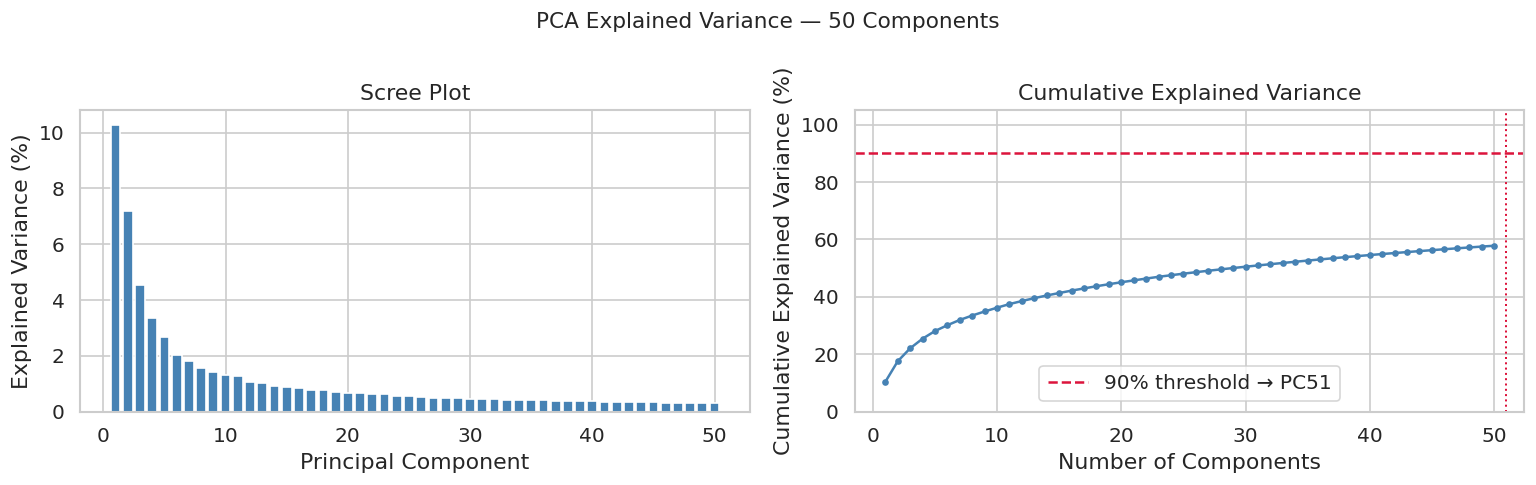

In [16]:
# ── Plot 3: Scree + cumulative explained variance (dual panel) ────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scree
comp_idx = np.arange(1, N_PCA_COMPONENTS + 1)
axes[0].bar(comp_idx, explained * 100, color='steelblue', edgecolor='white', width=0.8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot')

# Cumulative
axes[1].plot(comp_idx, cumulative * 100, marker='o', markersize=3,
             color='steelblue', linewidth=1.5)
axes[1].axhline(90, color='crimson', linestyle='--', linewidth=1.5,
                label=f'90% threshold → PC{n_for_90pct}')
axes[1].axvline(n_for_90pct, color='crimson', linestyle=':', linewidth=1.2)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].set_ylim(0, 105)

plt.suptitle(f'PCA Explained Variance — {N_PCA_COMPONENTS} Components', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'pca_explained_variance.png'), dpi=150, bbox_inches='tight')
plt.show()

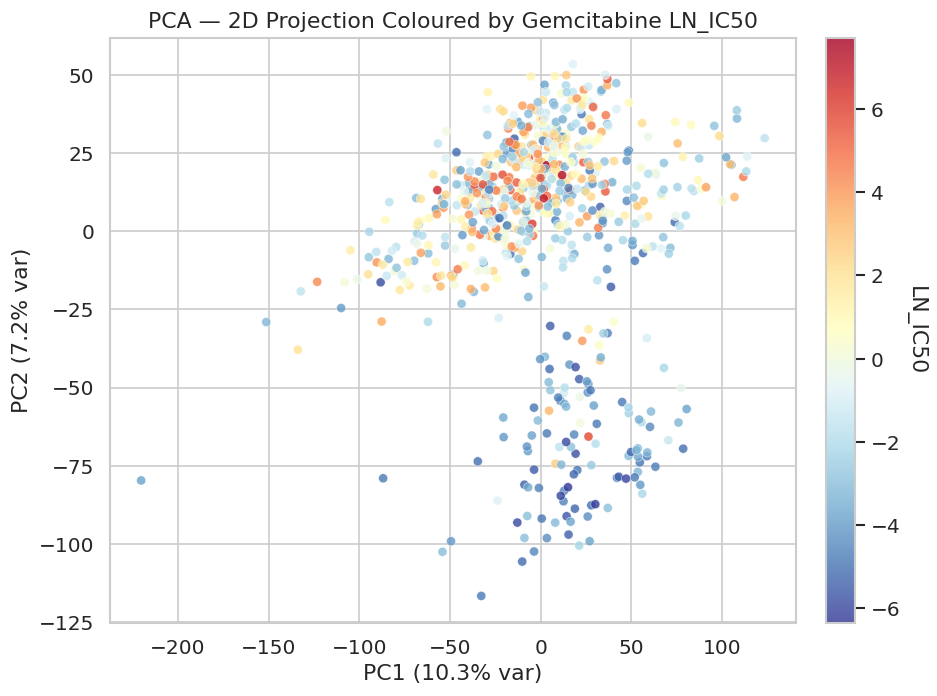

In [17]:
# ── Plot 4: 2D PCA scatter coloured by LN_IC50 ───────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                c=y, cmap='RdYlBu_r', s=30, alpha=0.8, edgecolors='white', linewidths=0.3)
cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('LN_IC50', rotation=270, labelpad=15)
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}% var)')
ax.set_title(f'PCA — 2D Projection Coloured by Gemcitabine LN_IC50')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'pca_scatter_ln_ic50.png'), dpi=150, bbox_inches='tight')
plt.show()

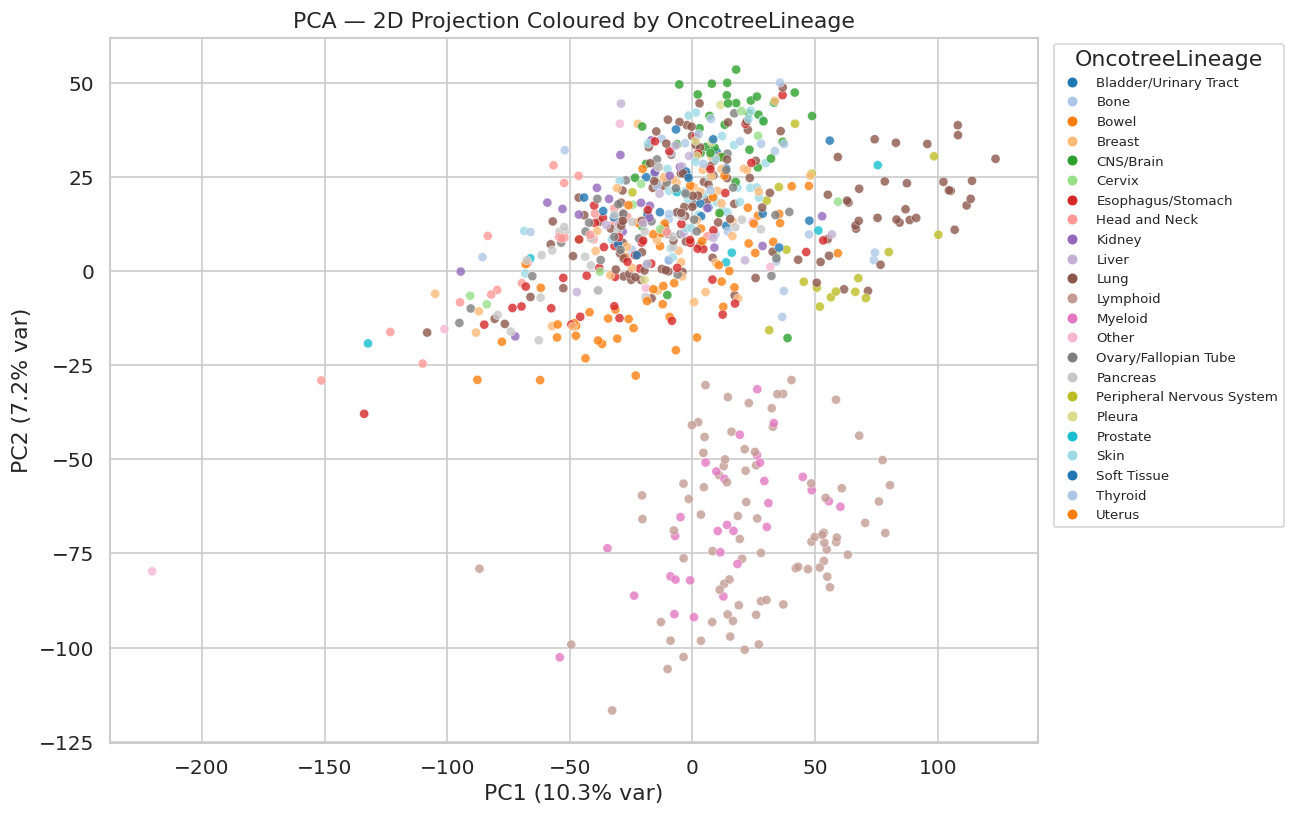

In [18]:
# ── Plot 5: 2D PCA scatter coloured by OncotreeLineage ────────────────────────
lineage_labels = meta['lineage_label'].values
unique_labels  = sorted(set(lineage_labels))
palette        = sns.color_palette('tab20', n_colors=len(unique_labels))
color_map      = {lbl: palette[i] for i, lbl in enumerate(unique_labels)}
point_colors   = [color_map[lbl] for lbl in lineage_labels]

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(X_pca[:, 0], X_pca[:, 1],
           c=point_colors, s=30, alpha=0.8, edgecolors='white', linewidths=0.3)

# Legend outside the plot
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[lbl],
           markersize=7, label=lbl)
    for lbl in unique_labels
]
ax.legend(handles=legend_elements, bbox_to_anchor=(1.01, 1), loc='upper left',
          fontsize=8, frameon=True, title='OncotreeLineage')

ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}% var)')
ax.set_title('PCA — 2D Projection Coloured by OncotreeLineage')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'pca_scatter_tissue_type.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Summary

| Plot | Filename |
|---|---|
| Gene variance distribution (full + zoomed) | `gene_variance_distribution.png` |
| \|Pearson r\| distribution with top-N cutoff | `pearson_correlation_distribution.png` |
| Top 30 genes bar chart, DCK/SLC29A1 highlighted | `top_genes_pearson.png` |
| Scree plot + cumulative explained variance | `pca_explained_variance.png` |
| PCA 2D scatter, coloured by LN_IC50 | `pca_scatter_ln_ic50.png` |
| PCA 2D scatter, coloured by OncotreeLineage | `pca_scatter_tissue_type.png` |

**Next step:** choose the dimensionality reduction strategy (top-N Pearson genes, PCA components, or both), then build the next notebook for train/val/test splitting and saving `X`, `y` arrays.